In [1]:
import pandas as pd
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    ExtraTreesClassifier,
    BaggingClassifier,
)
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import (
    LogisticRegression, 
    SGDClassifier, 
    Perceptron,
    PassiveAggressiveClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import pickle

In [ ]:
# df = pd.read_csv("./malicious_phish_preprocessed.csv")

benign        422930
defacement     94915
phishing       92405
malware        23639
Name: type, dtype: int64


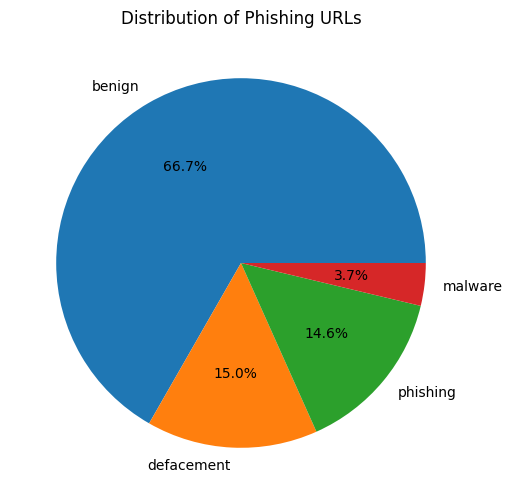

In [ ]:
# import matplotlib.pyplot as plt
# import os

# # Four types: benign, phishing, defacement and malware
# label_counts = df['type'].value_counts()

# print(label_counts)

# plt.figure(figsize=(10, 6))
# plt.pie(label_counts.values, labels=["benign", "defacement", "phishing", "malware"], autopct='%1.1f%%')
# plt.title('Distribution of Phishing URLs')
# plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
# plt.show()

# del label_counts

In [2]:
import pandas as pd

df = pd.read_csv("./malicious_phish_preprocessed.csv")
def numeric_labels(x):
    label_map = {
        "benign": 0,
        "defacement": 1,
        "phishing": 1,
        "malware": 1
    }

    typ = x["type"]

    return label_map[typ]

df["label"] = df.apply(numeric_labels, axis=1)
df["label"]
df = df.drop(columns=["", "Unnamed: 0.1"], errors="ignore")
df.to_csv("./malicious_phish_preprocessed.csv", index=False)

In [3]:
X = df.drop(columns=["Unnamed: 0", "url", "type"])
y = df["type"]
del df

In [4]:
import numpy as np

X = pd.get_dummies(X, columns=["tld"], drop_first=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

y = (y > 0).astype(int)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
[1 0 0 ... 1 1 1]


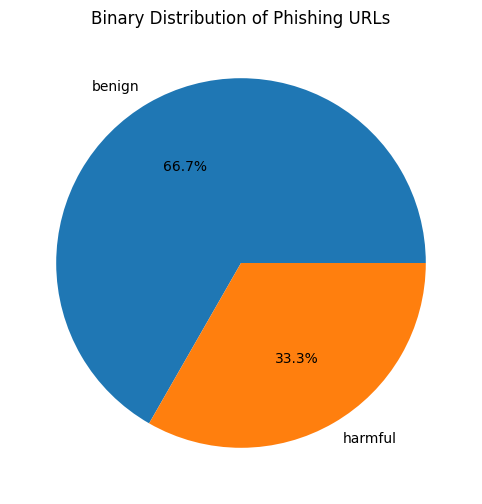

In [5]:
import matplotlib.pyplot as plt
import os

print(type(X))
print(type(y))
print(y)

unique, counts = np.unique(y, return_counts=True)

counter = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.pie(counter.values(), labels=["benign", "harmful"], autopct='%1.1f%%')
plt.title('Binary Distribution of Phishing URLs')
plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
plt.show()

del unique, counts, counter

In [8]:
import sys
sys.path.append("../Handlers")
from traintest import ClassificationModel2, add_to_json_array

In [9]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
with open("./models/logistic_regression_url.pkl", "wb") as f:
    pickle.dump(lr, f)

In [10]:
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

del lr

              precision    recall  f1-score   support

           0     0.7035    0.9380    0.8040     84729
           1     0.6193    0.2033    0.3061     42049

    accuracy                         0.6943    126778
   macro avg     0.6614    0.5706    0.5550    126778
weighted avg     0.6755    0.6943    0.6388    126778



In [11]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
with open("./models/ada_boost_url.pkl", "wb") as f:
    pickle.dump(ada, f)

In [12]:
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del ada

              precision    recall  f1-score   support

           0     0.9066    0.9643    0.9345     84729
           1     0.9174    0.7998    0.8546     42049

    accuracy                         0.9097    126778
   macro avg     0.9120    0.8821    0.8946    126778
weighted avg     0.9102    0.9097    0.9080    126778



In [13]:
bernb = BernoulliNB()
bernb.fit(X_train, y_train)
with open("./models/bernoulli_nb_url.pkl", "wb") as f:
    pickle.dump(bernb, f)

In [14]:
y_pred = bernb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del bernb

              precision    recall  f1-score   support

           0     0.7846    0.9101    0.8427     84729
           1     0.7327    0.4965    0.5919     42049

    accuracy                         0.7729    126778
   macro avg     0.7586    0.7033    0.7173    126778
weighted avg     0.7674    0.7729    0.7595    126778



In [15]:
mulnb = MultinomialNB()
mulnb.fit(X_train, y_train)
with open("./models/multinomial_nb_url.pkl", "wb") as f:
    pickle.dump(mulnb, f)

In [16]:
y_pred = mulnb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del mulnb

              precision    recall  f1-score   support

           0     0.7596    0.5770    0.6558     84729
           1     0.4258    0.6321    0.5088     42049

    accuracy                         0.5953    126778
   macro avg     0.5927    0.6045    0.5823    126778
weighted avg     0.6489    0.5953    0.6071    126778



In [17]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
with open("./models/decision_tree_url.pkl", "wb") as f:
    pickle.dump(dt, f)

In [18]:
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del dt

              precision    recall  f1-score   support

           0     0.9514    0.9463    0.9489     84729
           1     0.8930    0.9027    0.8978     42049

    accuracy                         0.9318    126778
   macro avg     0.9222    0.9245    0.9233    126778
weighted avg     0.9320    0.9318    0.9319    126778



In [19]:
rf = RandomForestClassifier(random_state=42, n_jobs=4)
rf.fit(X_train, y_train)
with open("./models/random_forest_url.pkl", "wb") as f:
    pickle.dump(rf, f)

In [20]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del rf

              precision    recall  f1-score   support

           0     0.9520    0.9631    0.9575     84729
           1     0.9238    0.9022    0.9129     42049

    accuracy                         0.9429    126778
   macro avg     0.9379    0.9326    0.9352    126778
weighted avg     0.9427    0.9429    0.9427    126778



In [21]:
ext = ExtraTreesClassifier(random_state=42, n_jobs=4)
ext.fit(X_train, y_train)
with open("./models/extra_trees_url.pkl", "wb") as f:
    pickle.dump(ext, f)

In [22]:
y_pred = ext.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del ext

              precision    recall  f1-score   support

           0     0.9411    0.9613    0.9511     84729
           1     0.9184    0.8787    0.8982     42049

    accuracy                         0.9339    126778
   macro avg     0.9298    0.9200    0.9246    126778
weighted avg     0.9336    0.9339    0.9335    126778



In [23]:
bag = BaggingClassifier(random_state=42, n_jobs=4)
bag.fit(X_train, y_train)
with open("./models/bagging_url.pkl", "wb") as f:
    pickle.dump(bag, f)

In [24]:
y_pred = bag.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del bag

              precision    recall  f1-score   support

           0     0.9502    0.9708    0.9604     84729
           1     0.9385    0.8975    0.9175     42049

    accuracy                         0.9465    126778
   macro avg     0.9443    0.9341    0.9389    126778
weighted avg     0.9463    0.9465    0.9462    126778



In [25]:
per = Perceptron(random_state=42, n_jobs=4)
per.fit(X_train, y_train)
with open("./models/perceptron_url.pkl", "wb") as f:
    pickle.dump(per, f)

In [26]:
y_pred = per.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del per

              precision    recall  f1-score   support

           0     0.7294    0.0157    0.0307     84729
           1     0.3326    0.9883    0.4977     42049

    accuracy                         0.3383    126778
   macro avg     0.5310    0.5020    0.2642    126778
weighted avg     0.5978    0.3383    0.1856    126778



In [27]:
pasag = PassiveAggressiveClassifier(random_state=42, n_jobs=4)
pasag.fit(X_train, y_train)
with open("./models/passive_aggressive_url.pkl", "wb") as f:
    pickle.dump(pasag, f)

In [28]:
y_pred = pasag.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del pasag

              precision    recall  f1-score   support

           0     0.8973    0.1127    0.2002     84729
           1     0.3527    0.9740    0.5178     42049

    accuracy                         0.3984    126778
   macro avg     0.6250    0.5434    0.3590    126778
weighted avg     0.7167    0.3984    0.3056    126778



In [29]:
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
with open("./models/linear_svc_url.pkl", "wb") as f:
    pickle.dump(svm, f)

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [30]:
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del svm

              precision    recall  f1-score   support

           0     0.6963    0.9764    0.8129     84729
           1     0.7486    0.1418    0.2384     42049

    accuracy                         0.6996    126778
   macro avg     0.7224    0.5591    0.5256    126778
weighted avg     0.7136    0.6996    0.6223    126778



In [31]:
sgd = SGDClassifier(random_state=42, n_jobs=4)
sgd.fit(X_train, y_train)
with open("./models/sgd_url.pkl", "wb") as f:
    pickle.dump(sgd, f)

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [33]:
y_pred = sgd.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del sgd

              precision    recall  f1-score   support

           0     0.6686    0.9990    0.8011     84729
           1     0.5287    0.0022    0.0044     42049

    accuracy                         0.6684    126778
   macro avg     0.5987    0.5006    0.4027    126778
weighted avg     0.6222    0.6684    0.5368    126778



In [34]:
knn = KNeighborsClassifier(n_jobs=4)
knn.fit(X_train, y_train)
with open("./models/knn_url.pkl", "wb") as f:
    pickle.dump(knn, f)

In [35]:
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del knn

              precision    recall  f1-score   support

           0     0.8187    0.9374    0.8741     84729
           1     0.8219    0.5818    0.6813     42049

    accuracy                         0.8195    126778
   macro avg     0.8203    0.7596    0.7777    126778
weighted avg     0.8198    0.8195    0.8101    126778



In [46]:
X_train = X_train.drop(columns=[
    'tld_2å~î\x05ä³7\x13g®x\x12\x9búä\x914²k\x07\x8bxâ`õ',
     "tld_7õú x\x1d\x0f'\x98}\x97ø\x814~æê¸a(_à\x7f",
     'tld__\x15\x01ãö%\x94p\x06bm\x0e',
     'tld_c³\x99^\x10\x91c·ù*%\x84yö\x96\x19g²2oê',
     'tld_t|jöäæ°!nqä\x8c\xad\x99þ\x9fÿ\x832á\x81\x1dº»sr\x04\x1dònú\x17z\x18b\x9dü\x9a\x98¤òy\x07\x1asõqµ',
     'tld_xn--p1ai',
     'tld_\x92\x96*\x8d',
 'tld_á>v>4z¢¶mù2<¯loâ\x8a¿3\x061\x08è',
 "tld_é¾¾t\x1e\x0e`(+}^«\x9d´i\x83\\\x83'f\x894\x18æ \x81\x16}cjñ",
 "Unnamed: 0.1"
], errors="ignore")
X_test = X_test.drop(columns=[
    'tld_2å~î\x05ä³7\x13g®x\x12\x9búä\x914²k\x07\x8bxâ`õ',
     "tld_7õú x\x1d\x0f'\x98}\x97ø\x814~æê¸a(_à\x7f",
     'tld__\x15\x01ãö%\x94p\x06bm\x0e',
     'tld_c³\x99^\x10\x91c·ù*%\x84yö\x96\x19g²2oê',
     'tld_t|jöäæ°!nqä\x8c\xad\x99þ\x9fÿ\x832á\x81\x1dº»sr\x04\x1dònú\x17z\x18b\x9dü\x9a\x98¤òy\x07\x1asõqµ',
     'tld_xn--p1ai',
     'tld_\x92\x96*\x8d',
 'tld_á>v>4z¢¶mù2<¯loâ\x8a¿3\x061\x08è',
 "tld_é¾¾t\x1e\x0e`(+}^«\x9d´i\x83\\\x83'f\x894\x18æ \x81\x16}cjñ",
 "Unnamed: 0.1"
], errors="ignore")
list(X_train.columns)

['url_length',
 'hostname_length',
 'path_length',
 'num_dots',
 'num_slashes',
 'num_digits',
 'num_special_chars',
 'has_https',
 'has_ip',
 'has_port',
 'has_at_symbol',
 'has_query',
 'num_params',
 'domain_in_path',
 'tld_0',
 'tld_1',
 'tld_10',
 'tld_100',
 'tld_101',
 'tld_102',
 'tld_103',
 'tld_104',
 'tld_105',
 'tld_106',
 'tld_107',
 'tld_108',
 'tld_109',
 'tld_11',
 'tld_110',
 'tld_111',
 'tld_112',
 'tld_113',
 'tld_114',
 'tld_115',
 'tld_116',
 'tld_117',
 'tld_118',
 'tld_119',
 'tld_12',
 'tld_120',
 'tld_121',
 'tld_122',
 'tld_123',
 'tld_124',
 'tld_125',
 'tld_126',
 'tld_127',
 'tld_128',
 'tld_129',
 'tld_13',
 'tld_130',
 'tld_131',
 'tld_132',
 'tld_133',
 'tld_134',
 'tld_135',
 'tld_136',
 'tld_137',
 'tld_138',
 'tld_139',
 'tld_14',
 'tld_140',
 'tld_141',
 'tld_142',
 'tld_143',
 'tld_144',
 'tld_145',
 'tld_146',
 'tld_147',
 'tld_148',
 'tld_149',
 'tld_15',
 'tld_150',
 'tld_151',
 'tld_152',
 'tld_153',
 'tld_154',
 'tld_155',
 'tld_156',
 'tld_157

In [47]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

NameError: name 'knn' is not defined

In [49]:
with open("./models/xgb_url.pkl", "wb") as f:
    pickle.dump(xgb, f)

In [50]:
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del xgb

              precision    recall  f1-score   support

           0     0.8829    0.9424    0.9117     84729
           1     0.8657    0.7483    0.8027     42049

    accuracy                         0.8780    126778
   macro avg     0.8743    0.8453    0.8572    126778
weighted avg     0.8772    0.8780    0.8755    126778

